In [4]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.collections import LineCollection
from scipy import stats
import seaborn as sns
from collections import Counter
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib
# import scienceplots
from matplotlib import rc
rc("text", usetex=False)
import warnings
warnings.filterwarnings('ignore')

sns.set(font_scale=2) 
sns.set_style("white")
# sns.set_style("ticks")
%matplotlib inline

# Helper function

In [5]:
def paired_line(data, lines, column1, cond1_ls, x_axis):
    plt.rcParams["figure.figsize"] = (3,10)
    ax = sns.pointplot(x=cond1_ls, y=column1, data=data)
    sns.despine()
    

def non_unique(l):
    def low(x):
        return x.lower() if isinstance(x, str) else x
    c = Counter(map(low, l))
    return [x for x in l if c[low(x)] > 1]

# AgRP chemogenetics

In [6]:
data = pd.read_csv('chemogenetics.csv', encoding='cp1252')
data = data[data['receptor'].isin(['Gq', 'mCher'])]
data_pre = data.groupby(['receptor', 'state_D2']).size().reset_index(name='n')
data_post = data.groupby(['receptor', 'state_after']).size().reset_index(name='n')
#data_D2 = data.groupby(['receptor', 'state_D2']).size().reset_index(name='n')
data_pre.loc[-1] = ['Gq', 'Agg+', 0]
data_pre.loc[-2] = ['mCher', 'Agg+', 0]

data_pre = data_pre.rename(columns = {'state_D2': 'state'})
data_post = data_post.rename(columns = {'state_after': 'state'})

data_t = pd.concat([data_pre, data_post], keys = ['CNO-', 'CNO+'])
data_t.reset_index(inplace = True)
data_t.loc[-1] = ['CNO+', 2,'mCher', 'Agg+', 0]

data_count = data.groupby(['receptor']).size().reset_index(name = 'count')
data_per = data_t.merge(data_count, how = 'outer', on = 'receptor')
data_per['percentage'] = data_per['n'] / data_per['count'] *100

## food intake

In [7]:
Gq_dat = data[data['receptor'] == 'Gq']
stat, p = stats.ttest_rel(Gq_dat['food_consumption_null'],
                           Gq_dat['food_consumption_CNO'])
print(p)

9.698631809291145e-05


In [8]:
columns = ['mice_ID', 'receptor', 'food_consumption_null', 'food_consumption_CNO']
filtered_df = data[columns].reset_index(drop = True).reset_index()
stacked_df = filtered_df[columns[-2:]].stack().reset_index()
stacked_df.columns = ['index', 'condition', 'food_consumption']
merged_df = pd.merge(filtered_df, stacked_df, on = 'index')

merged_df2 = merged_df.copy()
def encode_session(x):
  if x=='mCher':
    return 1
  else:
    return 0
merged_df2['receptor'] = merged_df2['receptor'].apply(encode_session)

def offset_session(row):
  if row['condition']=='food_consumption_null':
    return row['receptor']-0.2
  else:
    return row['receptor']+0.2
merged_df2['receptor'] = merged_df2.apply(offset_session, axis=1)

In [9]:
# merged_df2

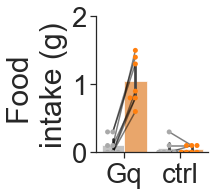

In [10]:
sns.set(font_scale=2.5) 
sns.set_style("ticks")
plt.subplots(figsize = [2,2.5])
sns.swarmplot(x = 'receptor', y = 'food_consumption', hue = 'condition', data = merged_df, dodge = True, 
              palette=['darkgray', 'Tab:orange'], order=['Gq', 'mCher'])
sns.barplot(x = 'receptor', y = 'food_consumption',  hue = 'condition', data = merged_df, 
            palette=['darkgray', 'Tab:orange'],alpha = 0.7, order=['Gq', 'mCher'])
sns.lineplot(x = 'receptor', y = 'food_consumption', hue='mice_ID', data=merged_df2,
                estimator=None,  palette= ['black'], legend=False, alpha = 0.5)

ax = plt.gca()
ax.set_xticklabels(('Gq', 'ctrl'))
ax.get_legend().remove()
plt.ylim(top=2)
plt.ylabel('Food \nintake (g)')
plt.xlabel('')
sns.despine()
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_1/linked_figure1/mchemo_food.pdf',dpi=300,bbox_inches='tight')

## parental behaviour

In [11]:
# _, p  =  stats.fisher_exact(d)
# print(p)

In [12]:
data_per = data_per[data_per['receptor'].isin(['mCher', 'Gq'])]

# add a small number to the zero values so that columns show up in the plot
data_per.loc[data_per['percentage'] == 0, ['percentage']] = 2

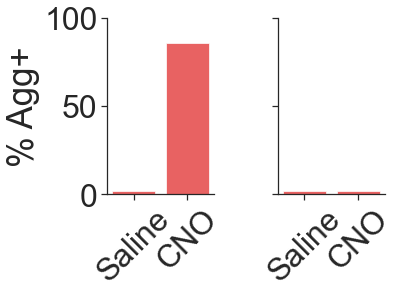

In [13]:
sns.set(font_scale=2.9) 
sns.set_style("ticks")

g = sns.catplot(x = 'level_0',
                y = 'percentage',
                col = 'receptor',
                data = data_per[data_per['state'] == 'Agg+'],
                kind = 'bar',
                alpha = 0.7, 
                palette = ['red'],
                aspect = 2.5/4) #2.5/4

g.set(xlabel = None)
g.set_xticklabels(rotation = 45)
g.set(ylabel = '% Agg+')
a1 = g.axes[0][0]
a2 = g.axes[0][1]
a1.set_title('', pad = 0)
a2.set_title('', pad = 0)
g.set_xticklabels( ('Saline', 'CNO'), rotation=45)



plt.ylim([0,100])
sns.despine()
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_1/linked_figure1/chemogenetics.pdf',dpi=300,bbox_inches='tight')

# optogenetics

## food intake

In [14]:
df = pd.read_csv('optogenetics.csv')
val = pd.read_csv('optogenetic_validation.csv')
df = pd.merge(df, val, on = ['mice_ID', 'implantation_area'])
conditions = df.pup_light_cond.dropna().unique()

In [15]:
df

,mice_ID,estrous_stage,surgery_date_x,implantation_area,pup_light_cond,status,state_latency,parental_status,experiment_date,Unnamed: 9,surgery_date_y,histology_validation,addition
0,JKAJ16.2h,NaN,24/05/2022,MPOA,spontaneous,Agg-,NaN,NaN,14/12/2022,NaN,24/05/2022,valid,NaN
1,JKAJ16.2h,P,24/05/2022,MPOA,instantaneous_on,Agg-,NaN,NaN,08/12/2022,NaN,24/05/2022,valid,NaN
2,JKAJ16.2h,P,24/05/2022,MPOA,instantaneous_off,Agg-,NaN,NaN,08/12/2022,NaN,24/05/2022,valid,NaN
3,JKAJ16.2h,M,24/05/2022,MPOA,15_lighton,Agg-,NaN,NaN,16/12/2022,NaN,24/05/2022,valid,NaN
4,JKAJ16.2h,D,24/05/2022,MPOA,30_lighton,Agg+,247.5,NaN,06/12/2022,NaN,24/05/2022,valid,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,JKAJ29.1e,NaN,NaN,MPOA_control,60_lighton_food,0.037,NaN,NaN,03/11/2023,NaN,NaN,NaN,NaN
160,JKAJ29.1h,NaN,NaN,MPOA_control,baseline_food,0.1,NaN,NaN,30/10/2023,NaN,NaN,valid,"implantation accurate, unilateral viral injection"
161,JKAJ29.1h,NaN,NaN,MPOA_control,60_post_food,0.28,NaN,NaN,01/11/2023,NaN,NaN,valid,"implantation accurate, unilateral viral injection"
162,JKAJ29.1h,M,NaN,MPOA_control,30_lighton,Agg-,NaN,NaN,03/11/2023,NaN,NaN,valid,"implantation accurate, unilateral viral injection"


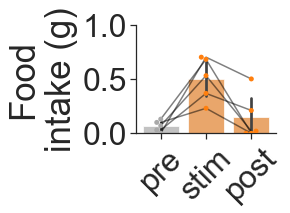

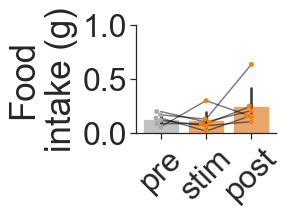

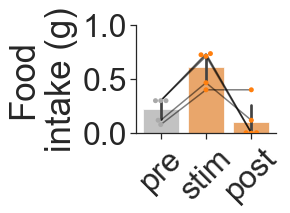

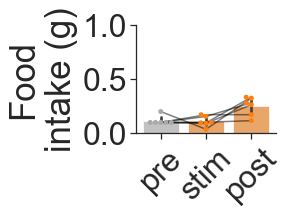

In [17]:
for area in df.implantation_area.unique():
    food_df = df[(df.pup_light_cond.isin(conditions[-3:])) & (df.histology_validation !='invalid')&(df.implantation_area == area)]
    food_df["status"] = pd.to_numeric(food_df.status)
    food_df["parental_status"] = pd.to_numeric(food_df.parental_status)

    food_df.pup_light_cond = pd.Categorical(food_df.pup_light_cond, 
                            categories=conditions[-3:],
                            ordered=True)
    

    # compute stats for food intake
    # stat, p = stats.ttest_rel(food_df[food_df.pup_light_cond == '60_lighton_food'].status,
    #                         food_df[food_df.pup_light_cond == '60_post_food'].status)
    # print(p, area)


    plt.subplots(figsize = [2.5,2])
    ax = sns.swarmplot(x = 'pup_light_cond', y = 'status', data = food_df, palette=['darkgray', 'Tab:orange', 'Tab:orange'])
    ax = sns.barplot(x = 'pup_light_cond', y = 'status', data = food_df, palette=['darkgray', 'Tab:orange', 'Tab:orange'], alpha=0.7)
    ax = sns.lineplot(x="pup_light_cond", y="status", hue='mice_ID', data=food_df,
                estimator=None,  palette=['black'], legend=False, alpha = 0.5)
    
    locs, labels = plt.xticks()
    plt.xticks(locs,(['pre','stim', 'post']), rotation = 45)
    plt.ylabel('Food\nintake (g)')
    plt.xlabel('')
    plt.ylim(0,1)
    plt.title('')
    ax.yaxis.set_major_locator(plt.MaxNLocator(2))
    sns.despine()
#     output_filename = os.path.join('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_3/linked_figures/', f'{area}_food.pdf')
#     plt.savefig(output_filename, dpi=300, bbox_inches='tight', transparent=True)

#     plt.savefig(f'output_figures/{area}_food.pdf',dpi = 300,bbox_inches='tight')
# plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_3/linked_figures/{area}_food.pdf.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [18]:
## food intake latency and aggressive behaviour latency correlation
corr = pd.merge(df[df.pup_light_cond == '60_lighton_food'], df[(df.pup_light_cond== '30_lighton') &(df.implantation_area == 'MPOA')], on = ['mice_ID', 'implantation_area'])
corr["status_x"] = pd.to_numeric(corr.status_x)
corr["parental_status_y"] = pd.to_numeric(corr.parental_status_y)
corr["parental_status_x"] = pd.to_numeric(corr.parental_status_x)
corr = corr[corr.histology_validation_x != 'invalid']

(-96.42081474872364, 500.0)

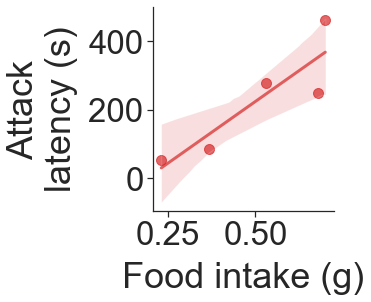

In [19]:
sns.set(font_scale=3)
sns.set_style("ticks")
sns.lmplot(x = 'status_x',
            y = 'state_latency_y',
            data = corr, #aspect = 1.8/2,
            scatter_kws={'s':100, 'color':'Tab:red', 'alpha': 0.7}, 
            line_kws = {'lw':3, 'color':'Tab:red', 'alpha': 0.7})
sns.despine()
plt.xlabel('Food intake (g)', labelpad=10)
plt.ylabel('Attack\nlatency (s)', labelpad=10)
plt.ylim(top=500)
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_3/linked_figures/attack_food_corr.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [20]:
#test stats relationship
model = smf.ols('state_latency_y ~ status_x', data=corr).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        state_latency_y   R-squared:                       0.784
Model:                            OLS   Adj. R-squared:                  0.711
Method:                 Least Squares   F-statistic:                     10.86
Date:                Mon, 22 Apr 2024   Prob (F-statistic):             0.0459
Time:                        22:18:15   Log-Likelihood:                -28.211
No. Observations:                   5   AIC:                             60.42
Df Residuals:                       3   BIC:                             59.64
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -135.0202    116.036     -1.164      0.329    -504.299     234.259
status_x     717.4315    217.670      3.296      0.046      24.709    1410.154
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   1.434
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.304
Skew:                          -0.240   Prob(JB):                        0.859
Kurtosis:                       1.892   Cond. No.                         6.95
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## parental behaviour

In [21]:
par_df = df[(df.pup_light_cond.isin(conditions[:6]))& (df.histology_validation != 'invalid')]
count = par_df.groupby(['implantation_area', 'pup_light_cond', 'status']).size().unstack(fill_value=0).stack().reset_index(name = 'count')
ns = par_df.groupby(['implantation_area','pup_light_cond']).size().reset_index(name='n')
props = pd.merge(count, ns, on = ['implantation_area','pup_light_cond'])
props['props'] = props['count'] / props['n']
props.pup_light_cond = pd.Categorical(props.pup_light_cond, 
                      categories=conditions[:6],
                      ordered=True)
props.implantation_area = pd.Categorical(props.implantation_area, 
                      categories=['MPOA', 'LPOA', 'PVH'],
                      ordered=True)

In [22]:
table_df = par_df[(par_df.implantation_area == 'MPOA') & (par_df.pup_light_cond.isin(['30_lighton', '30_lightoff']))]
table = pd.crosstab(table_df.pup_light_cond, table_df.status)
chi, p, dof, expected = stats.chi2_contingency(table)
print(table, p)

status          Agg+  Agg-
pup_light_cond            
30_lightoff        0     5
30_lighton         5     0 0.01141203638600166


In [23]:
plot_cond = ['30_lighton']
plot_df = props[(props.status == 'Agg+')& (props.pup_light_cond.isin(plot_cond))]
plot_df.pup_light_cond = pd.Categorical(plot_df.pup_light_cond, 
                      categories=plot_cond,
                      ordered=True)

plot_df2 = plot_df.loc[(plot_df['implantation_area'] == 'LPOA') | (plot_df['implantation_area'] == 'PVH')]
plot_df2['prob'] = plot_df2.props * 100
plot_df2

,implantation_area,pup_light_cond,status,count,n,props,prob
2,LPOA,30_lighton,Agg+,1,6,0.166667,16.666667
22,PVH,30_lighton,Agg+,1,5,0.200000,20.000000


In [24]:
plot_df2

,implantation_area,pup_light_cond,status,count,n,props,prob
2,LPOA,30_lighton,Agg+,1,6,0.166667,16.666667
22,PVH,30_lighton,Agg+,1,5,0.200000,20.000000


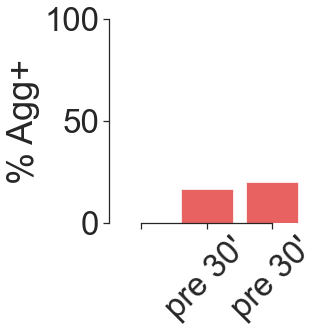

In [25]:
sns.set(rc={"figure.figsize": (2, 2)})
sns.set(font_scale=3) 
sns.set_style("ticks")

g = sns.catplot(x = 'implantation_area',
                y = 'prob',
                data = plot_df2,
                kind = 'bar',
                alpha = 0.7, 
                palette = ['red'],
                aspect = 1)

g.set(xlabel = None)
plt.ylim([0,100])
plt.ylabel('% Agg+')
g.set_xticklabels(('','pre 30\'', 'pre 30\''), rotation=45)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_1/linked_figure1/opto_area_parental.pdf',dpi=600,bbox_inches='tight')

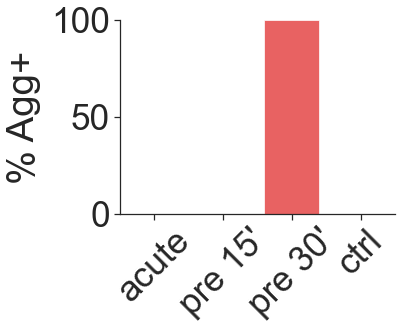

In [26]:
sns.set(rc={"figure.figsize": (2, 6)})
sns.set(font_scale=3.2) 
sns.set_style("ticks")

plot_cond = ['spontaneous', 'instantaneous_on', '30_lighton', '30_lightoff']

plot_df = props[(props.status == 'Agg+')& (props.pup_light_cond.isin(plot_cond))]
plot_df.pup_light_cond = pd.Categorical(plot_df.pup_light_cond, 
                      categories=plot_cond,
                      ordered=True)

plot_df['prob'] = plot_df.props * 100

g = sns.catplot(x = 'pup_light_cond',
                y = 'prob',
                data = plot_df[plot_df.implantation_area == 'MPOA'],
                kind = 'bar',
                alpha = 0.7, 
                palette = ['red'],aspect = 1.4)

g.set(xlabel = None)
plt.ylim([0,100])
plt.xticks(rotation = 90)
plt.ylabel('% Agg+', labelpad=10)
g.set_xticklabels( ('acute', 'pre 15\'','pre 30\'', 'ctrl'), rotation=45)
sns.despine(trim=False)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_1/linked_figure1/opto_parental.pdf',
#             dpi=600,bbox_inches='tight')